In [ ]:
# ═══════════════════════════════
# CELL 0: Environment Setup
# ═══════════════════════════════
import os
import sys
import subprocess

# NCCL/CUDA stability flags for notebook DataParallel.
os.environ.setdefault('NCCL_DEBUG', 'WARN')
os.environ.setdefault('NCCL_SOCKET_FAMILY', 'AF_INET')
os.environ.setdefault('NCCL_COMM_BLOCKING_WAIT', '1')
os.environ.setdefault('NCCL_P2P_DISABLE', '0')
os.environ.setdefault('CUDA_LAUNCH_BLOCKING', '1')
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# GPU mode: 'single' avoids DataParallel forward hangs in some notebook runtimes.
os.environ.setdefault('DEEPLENSE_GPU_MODE', 'single')
if os.environ['DEEPLENSE_GPU_MODE'].strip().lower() == 'single':
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
print(f"DEEPLENSE_GPU_MODE={os.environ['DEEPLENSE_GPU_MODE']}")

_ = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown', 'torch-fidelity'], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print('Packages ready')

Packages ready


Downloading...
From (original): https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA
From (redirected): https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA&confirm=t&uuid=ccca5c99-12b1-4ed2-8f49-e32d9a6e245f
To: /kaggle/working/task8_generation.zip
100%|██████████| 304M/304M [00:02<00:00, 120MB/s]


Extracted dataset to: /kaggle/working/task8_data


Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=fd73fa5f-8b2d-4f0e-ae5f-726957a42e0b
To: /kaggle/working/task1_lensing.zip
100%|██████████| 1.13G/1.13G [00:10<00:00, 103MB/s]


Extracted dataset to: /kaggle/working/task1_data
Saved pseudo labels: /kaggle/working/task8_pseudo_labels.json
Cluster distribution:
  cluster 0: 3420
  cluster 1: 3015
  cluster 2: 1820
  cluster 3: 1745


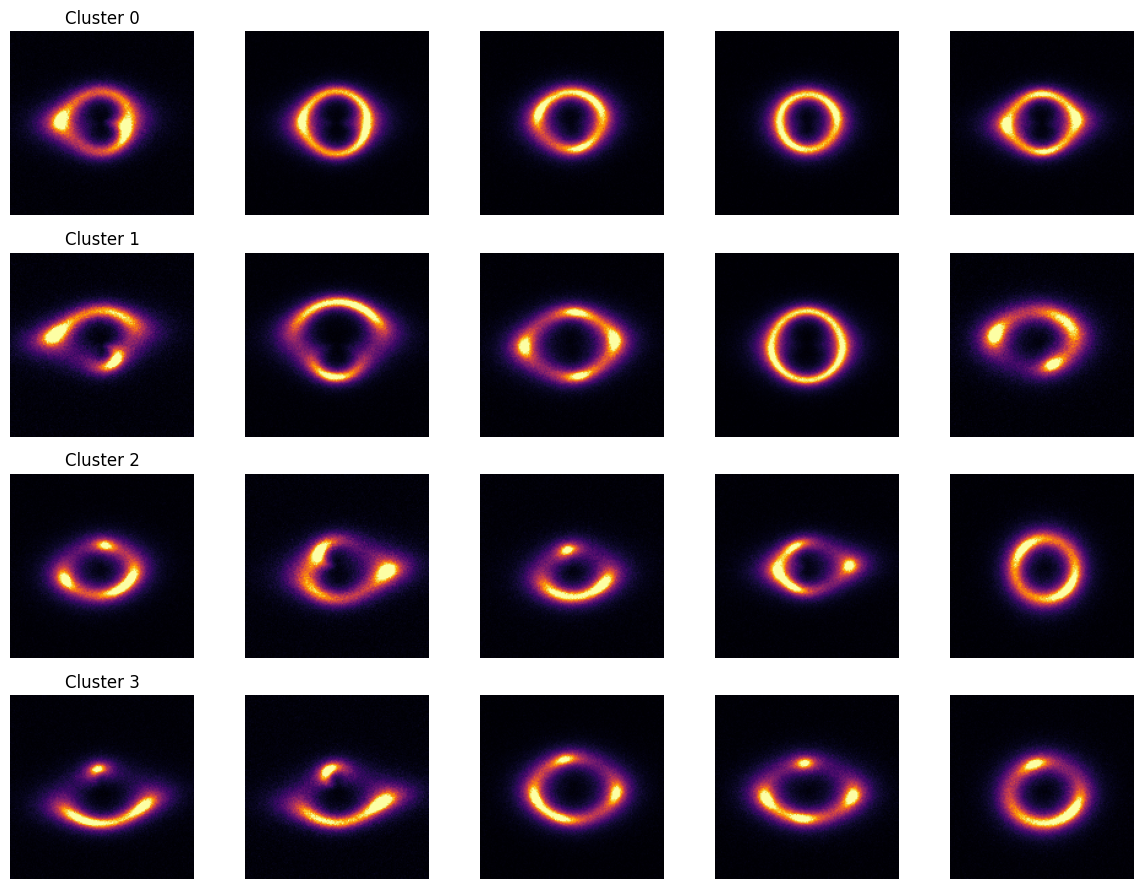

Cell 1 complete: config + pseudo-labels ready


In [ ]:
# ═══════════════════════════════
# CELL 1: Imports, Config, K-Means Pseudo-Labels
# ═══════════════════════════════
import os
import warnings
import copy
import glob
import zipfile
import json
import time
import random
from collections import Counter

import gdown
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr, entropy
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
import torchvision.models as tv_models
from torchvision.utils import make_grid, save_image

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

IMG_SIZE = 64
IN_CH = 1
PATCH_SIZE = 4
N_TOKENS = (IMG_SIZE // PATCH_SIZE) ** 2
HIDDEN_DIM = 768
DEPTH = 12
NUM_HEADS = 12
FFN_RATIO = 4
DROPOUT = 0.1
NUM_CLUSTERS = 3
NUM_CLASSES = 4
NULL_CLASS = 3

BATCH_SIZE = 16
EPOCHS = 500
LR = 4e-4
LR_MIN = 1e-5
WEIGHT_DECAY = 0.05
GRAD_CLIP = 1.0
EMA_DECAY = 0.9952
P_CFG_DROP = 0.15
SAVE_EVERY = 10
EULER_STEPS = 100
CFG_SCALE = 2.0
CFG_SWEEP_VALUES = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
TEMP_SWEEP_VALUES = [0.75, 0.80, 0.85, 0.90]
USE_HEUN_SAMPLER = True
N_FID_IMAGES = 5000
VALID_GEN_CLASSES = [0, 1, 2]
ENABLE_CKPT_AVERAGING = True
CKPT_AVG_LAST_N = 4

# Training toggles for v2
FORCE_NEW_ARCH_TRAIN = True
USE_GLOBAL_OT = True
LOGIT_CURRICULUM_ENABLE = True
LOGIT_CURRICULUM_MU = 0.0
LOGIT_CURRICULUM_SIGMA = 1.0
LOGIT_CURRICULUM_PHASE1_END = 120
USE_MIN_SNR_LOSS = True
MIN_SNR_GAMMA = 5.0

# Optional external resume checkpoints
RESUME_LAST_EPOCH = None
RESUME_LATEST_PTH = ''
RESUME_BEST_PTH = ''

TASK8_ID = '1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA'
TASK1_ID = '1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ'
WORK_DIR = '/kaggle/working' if os.path.exists('/kaggle') else os.path.abspath('.')
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints_task8')
GEN_DIR = os.path.join(WORK_DIR, 'fid_fake_rgb')
REAL_DIR = os.path.join(WORK_DIR, 'fid_real_rgb')
TASK8_ZIP = os.path.join(WORK_DIR, 'task8_generation.zip')
TASK1_ZIP = os.path.join(WORK_DIR, 'task1_lensing.zip')
TASK8_ROOT = os.path.join(WORK_DIR, 'task8_data')
TASK1_ROOT = os.path.join(WORK_DIR, 'task1_data')
PSEUDO_LABELS = os.path.join(WORK_DIR, 'task8_pseudo_labels.json')
CKPT_BEST = os.path.join(CKPT_DIR, 'dit_otfm_best.pth')
CKPT_LATEST = os.path.join(CKPT_DIR, 'dit_otfm_latest.pth')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 2
GPU_MODE = os.environ.get('DEEPLENSE_GPU_MODE', 'single').strip().lower()
USE_DATAPARALLEL = bool(GPU_MODE in ('multi', 'dataparallel'))

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(TASK8_ROOT, exist_ok=True)
os.makedirs(TASK1_ROOT, exist_ok=True)

def get_safe_autocast_dtype() -> torch.dtype:
    if DEVICE.type != 'cuda' or torch.cuda.device_count() == 0:
        return torch.float32
    major, _minor = torch.cuda.get_device_capability(0)
    return torch.bfloat16 if major >= 8 else torch.float16

AUTOCAST_DTYPE = get_safe_autocast_dtype()
AUTOCAST_ENABLED = bool(DEVICE.type == 'cuda' and AUTOCAST_DTYPE in (torch.float16, torch.bfloat16))

def _download_and_extract(file_id: str, zip_path: str, out_dir: str, marker_name: str):
    marker = os.path.join(out_dir, marker_name)
    if os.path.exists(marker):
        print(f'Skip download: {marker_name} exists')
        return
    if not os.path.exists(zip_path):
        gdown.download(id=file_id, output=zip_path, quiet=False)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(out_dir)
    with open(marker, 'w', encoding='utf-8') as f:
        f.write('done')
    print(f'Extracted dataset to: {out_dir}')

_download_and_extract(TASK8_ID, TASK8_ZIP, TASK8_ROOT, '.task8.done')
_download_and_extract(TASK1_ID, TASK1_ZIP, TASK1_ROOT, '.task1.done')

def to_grayscale_2d(img_np: np.ndarray) -> np.ndarray:
    arr = np.asarray(img_np, dtype=np.float32)
    arr = np.squeeze(arr)
    if arr.ndim == 0:
        raise ValueError(f'Invalid scalar image array with shape {np.asarray(img_np).shape}')
    if arr.ndim == 1:
        side = int(round(np.sqrt(arr.size)))
        if side * side == arr.size:
            arr = arr.reshape(side, side)
        else:
            raise ValueError(f'Cannot reshape 1D image array of length {arr.size} to square image')
    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[-1] == 1:
            arr = arr[..., 0]
        elif arr.shape[0] in (3, 4) and arr.shape[-1] not in (3, 4):
            arr = np.moveaxis(arr, 0, -1)
        if arr.ndim == 3:
            arr = arr.mean(axis=-1)
    if arr.ndim != 2:
        raise ValueError(f'Expected 2D grayscale image, got shape {arr.shape}')
    return arr

def percentile_norm(img_np: np.ndarray, p_low: float = 1.0, p_high: float = 99.0) -> np.ndarray:
    arr = to_grayscale_2d(img_np)
    lo = np.percentile(arr, p_low)
    hi = np.percentile(arr, p_high)
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / max(hi - lo, 1e-6)
    arr = arr * 2.0 - 1.0
    return arr

all_npy = sorted(glob.glob(os.path.join(TASK8_ROOT, '**', '*.npy'), recursive=True))
if len(all_npy) == 0:
    raise FileNotFoundError(f'No .npy files found under {TASK8_ROOT}')

if not os.path.exists(PSEUDO_LABELS):
    features = []
    for p in all_npy:
        arr = np.load(p)
        arr = percentile_norm(arr)
        pil = Image.fromarray(((arr + 1.0) * 127.5).astype(np.uint8))
        pil = pil.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        arr64 = np.asarray(pil, dtype=np.float32) / 127.5 - 1.0
        features.append(arr64.reshape(-1))
    features = np.stack(features, axis=0)
    km = MiniBatchKMeans(n_clusters=NUM_CLUSTERS, random_state=SEED, n_init=10, batch_size=512)
    labels = km.fit_predict(features)
    mapping = {all_npy[i]: int(labels[i]) for i in range(len(all_npy))}
    with open(PSEUDO_LABELS, 'w', encoding='utf-8') as f:
        json.dump(mapping, f)
    print('Saved pseudo labels:', PSEUDO_LABELS)
else:
    with open(PSEUDO_LABELS, 'r', encoding='utf-8') as f:
        mapping = json.load(f)
    print('Loaded existing pseudo labels:', PSEUDO_LABELS)

counter = Counter(mapping.values())
print('Cluster distribution:')
for k in range(NUM_CLUSTERS):
    print(f'  cluster {k}: {counter.get(k, 0)}')

fig, axes = plt.subplots(NUM_CLUSTERS, 5, figsize=(12, 9))
for c in range(NUM_CLUSTERS):
    chosen = [p for p in all_npy if mapping.get(p, -1) == c][:5]
    for j in range(5):
        ax = axes[c, j]
        if j < len(chosen):
            arr = percentile_norm(np.load(chosen[j]))
            ax.imshow(arr, cmap='inferno')
        ax.axis('off')
        if j == 0:
            ax.set_title(f'Cluster {c}')
plt.tight_layout()
plt.show()
print('Cell 1 complete: config + pseudo-labels ready')

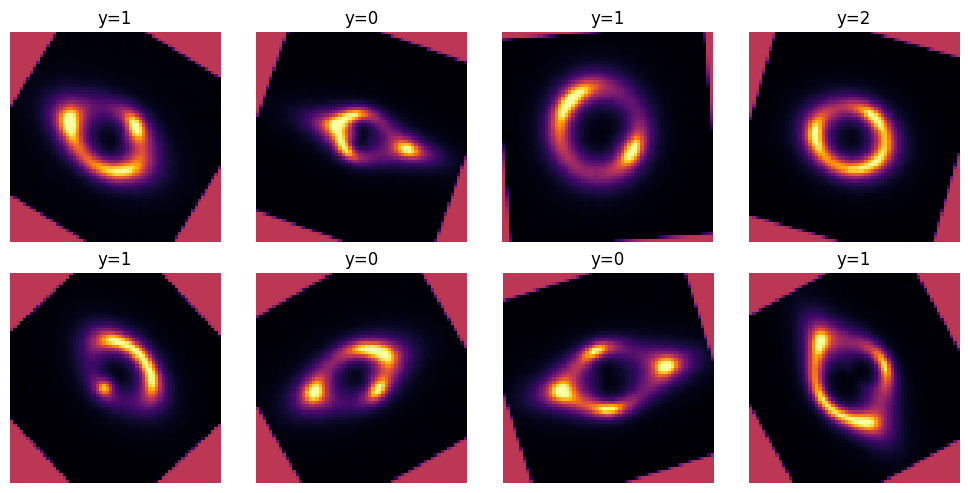

Cell 2 complete: DataLoader smoke test passed


In [3]:
# ═══════════════════════════════
# CELL 2: Dataset & DataLoader
# ═══════════════════════════════
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode

class FlowLensingDataset(Dataset):
    def __init__(self, root, pseudo_label_file, transform=None):
        self.root = root
        self.paths = sorted(glob.glob(os.path.join(root, '**', '*.npy'), recursive=True))
        with open(pseudo_label_file, 'r', encoding='utf-8') as f:
            self.labels = json.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = np.load(path).astype(np.float32)
        img = percentile_norm(img)
        pil = Image.fromarray(((img + 1.0) * 127.5).astype(np.uint8))
        pil = pil.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        x = torch.from_numpy(np.asarray(pil, dtype=np.float32) / 127.5 - 1.0).unsqueeze(0)  # (1,64,64)
        if self.transform is not None:
            x = self.transform(x)
        y = torch.tensor(int(self.labels[path]), dtype=torch.long)
        return x, y

TRAIN_TF = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(180, interpolation=InterpolationMode.BILINEAR),
])
EVAL_TF = transforms.Compose([])

ds_train = FlowLensingDataset(TASK8_ROOT, PSEUDO_LABELS, transform=TRAIN_TF)
dl_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

xb, yb = next(iter(dl_train))
assert xb.shape == (BATCH_SIZE, 1, 64, 64), f'Unexpected image shape: {xb.shape}'
assert yb.shape == (BATCH_SIZE,), f'Unexpected label shape: {yb.shape}'
assert xb.dtype == torch.float32, f'Expected float32 image tensor, got {xb.dtype}'
assert yb.dtype == torch.long, f'Expected long label tensor, got {yb.dtype}'

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(xb[i, 0].numpy(), cmap='inferno', vmin=-1, vmax=1)
    ax.set_title(f'y={int(yb[i])}')
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Cell 2 complete: DataLoader smoke test passed')

In [ ]:
# ═══════════════════════════════
# CELL 3: DiT Architecture
# ═══════════════════════════════
import math
import numpy as np
import torch
import torch.nn as nn

class SinusoidalPosEmb2D(nn.Module):
    def __init__(self, h_tokens: int, w_tokens: int, dim: int):
        super().__init__()
        assert dim % 4 == 0
        self.h_tokens = h_tokens
        self.w_tokens = w_tokens
        self.dim = dim

    def forward(self):
        y = torch.arange(self.h_tokens, dtype=torch.float32)
        x = torch.arange(self.w_tokens, dtype=torch.float32)
        yy, xx = torch.meshgrid(y, x, indexing='ij')
        omega = torch.arange(self.dim // 4, dtype=torch.float32)
        omega = 1.0 / (10000 ** (omega / max((self.dim // 4) - 1, 1)))
        out_y = yy.reshape(-1, 1) * omega.reshape(1, -1)
        out_x = xx.reshape(-1, 1) * omega.reshape(1, -1)
        pe = torch.cat([torch.sin(out_y), torch.cos(out_y), torch.sin(out_x), torch.cos(out_x)], dim=1)
        return pe.unsqueeze(0)  # (1, 256, HIDDEN_DIM)

class DiTBlock(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=12, ffn_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)
        self.norm2 = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True, dropout=dropout)
        ffn_hidden = hidden_dim * ffn_ratio
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, ffn_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_hidden, hidden_dim),
            nn.Dropout(dropout),
        )
        self.adaLN = nn.Sequential(nn.SiLU(), nn.Linear(hidden_dim, hidden_dim * 6))
        nn.init.zeros_(self.adaLN[-1].weight)
        nn.init.zeros_(self.adaLN[-1].bias)

    def forward(self, x, cond):
        params = self.adaLN(cond)
        shift1, scale1, gate1, shift2, scale2, gate2 = params.chunk(6, dim=1)
        gate1 = gate1.unsqueeze(1).tanh()
        gate2 = gate2.unsqueeze(1).tanh()

        h = self.norm1(x) * (1 + scale1.unsqueeze(1)) + shift1.unsqueeze(1)
        h, _ = self.attn(h, h, h, need_weights=False)
        x = x + gate1 * h

        h = self.norm2(x) * (1 + scale2.unsqueeze(1)) + shift2.unsqueeze(1)
        h = self.ffn(h)
        x = x + gate2 * h
        return x

class DiT(nn.Module):
    def __init__(self):
        super().__init__()
        # Self-conditioning doubles input channels: x + x_self_cond.
        self.patch = nn.Conv2d(IN_CH * 2, HIDDEN_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
        self.null_cond = nn.Parameter(torch.zeros(1, IN_CH, IMG_SIZE, IMG_SIZE))
        pe = SinusoidalPosEmb2D(IMG_SIZE // PATCH_SIZE, IMG_SIZE // PATCH_SIZE, HIDDEN_DIM)()
        self.register_buffer('pos_embed', pe, persistent=False)

        self.time_mlp = nn.Sequential(
            nn.Linear(256, HIDDEN_DIM),
            nn.SiLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
        )
        self.class_emb = nn.Embedding(NUM_CLASSES, HIDDEN_DIM)
        nn.init.zeros_(self.class_emb.weight)

        self.blocks = nn.ModuleList([
            DiTBlock(hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS, ffn_ratio=FFN_RATIO, dropout=DROPOUT)
            for _ in range(DEPTH)
        ])

        self.norm_f = nn.LayerNorm(HIDDEN_DIM, elementwise_affine=False, eps=1e-6)
        self.adaLN_f = nn.Sequential(nn.SiLU(), nn.Linear(HIDDEN_DIM, HIDDEN_DIM * 2))
        self.linear = nn.Linear(HIDDEN_DIM, PATCH_SIZE * PATCH_SIZE * IN_CH)
        nn.init.zeros_(self.adaLN_f[-1].weight)
        nn.init.zeros_(self.adaLN_f[-1].bias)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def time_embed(self, t):
        freq = torch.exp(-math.log(10000.0) * torch.arange(128, device=t.device, dtype=torch.float32) / 127.0)
        x = t[:, None].float() * freq[None, :]
        emb = torch.cat([torch.sin(x), torch.cos(x)], dim=-1)  # (B,256)
        return self.time_mlp(emb)  # (B,HIDDEN_DIM)

    def unpatchify(self, h):
        B = h.shape[0]
        h = h.reshape(B, 16, 16, 4, 4, 1)
        h = h.permute(0, 5, 1, 3, 2, 4)  # (B,1,16,4,16,4)
        h = h.reshape(B, 1, 64, 64)
        return h

    def forward(self, x, t, y, x_self_cond=None):
        if x_self_cond is None:
            x_self_cond = self.null_cond.expand(x.shape[0], -1, -1, -1)
        x_in = torch.cat([x, x_self_cond], dim=1)

        h = self.patch(x_in)  # (B,HIDDEN_DIM,16,16)
        h = h.flatten(2).transpose(1, 2)  # (B,256,HIDDEN_DIM)
        h = h + self.pos_embed.to(h.dtype)

        cond = self.time_embed(t) + self.class_emb(y)  # (B,HIDDEN_DIM)
        for blk in self.blocks:
            h = blk(h, cond)

        shift, scale = self.adaLN_f(cond).chunk(2, dim=1)
        h = self.norm_f(h) * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)
        h = self.linear(h)  # (B,256,16)
        h = self.unpatchify(h)
        return h

model_smoke = DiT().to(DEVICE)
with torch.no_grad():
    xx = torch.randn(2, 1, 64, 64, device=DEVICE)
    tt = torch.rand(2, device=DEVICE)
    yy = torch.zeros(2, dtype=torch.long, device=DEVICE)
    oo = model_smoke(xx, tt, yy)

test1 = tuple(oo.shape) == (2, 1, 64, 64)
test2 = not torch.isnan(oo).any().item()
n_params = sum(p.numel() for p in model_smoke.parameters())
test3 = (60_000_000 <= n_params <= 220_000_000)

print(f'Test 1 shape check: {"PASS" if test1 else "FAIL"}')
print(f'Test 2 no NaN check: {"PASS" if test2 else "FAIL"}')
print(f'Test 3 param range check: {"PASS" if test3 else "FAIL"}')
assert test1 and test2 and test3
print(f'Parameter count: {n_params:,}')
print('Cell 3 complete: DiT architecture ready')

Test 1 shape check: PASS
Test 2 no NaN check: PASS
Test 3 param range check: PASS
Parameter count: 32,476,432
Cell 3 complete: DiT architecture ready


In [ ]:
# ═══════════════════════════════
# CELL 4: EMA & Utilities
# ═══════════════════════════════
import os
import time
import copy
import warnings
import numpy as np
import torch
from scipy.optimize import linear_sum_assignment

class EMA:
    def __init__(self, model: torch.nn.Module, decay: float = 0.9995):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: torch.nn.Module):
        msd = model.state_dict()
        ssd = self.shadow.state_dict()
        for k in ssd.keys():
            if ssd[k].dtype.is_floating_point:
                ssd[k].mul_(self.decay).add_(msd[k].detach(), alpha=1.0 - self.decay)
            else:
                ssd[k].copy_(msd[k])

def ot_pair(x0: torch.Tensor, x1: torch.Tensor) -> torch.Tensor:
    # x0, x1: (B, C, H, W)
    b = x0.shape[0]
    if b == 1:
        return x1
    t0 = time.time()
    x0_flat = x0.reshape(b, -1).detach().cpu().float().numpy()
    x1_flat = x1.reshape(b, -1).detach().cpu().float().numpy()
    cost = np.sum((x0_flat[:, None, :] - x1_flat[None, :, :]) ** 2, axis=-1)
    row_ind, col_ind = linear_sum_assignment(cost)
    col_ind = torch.as_tensor(col_ind, device=x1.device, dtype=torch.long)
    dt = time.time() - t0
    if dt > 2.0:
        warnings.warn(f'OT pairing took {dt:.2f}s for batch size {b}', RuntimeWarning)
    return x1.index_select(0, col_ind)

def _unwrap_model(model: torch.nn.Module) -> torch.nn.Module:
    return model.module if isinstance(model, torch.nn.DataParallel) else model

def save_checkpoint(path, model, ema, optimizer, scheduler, scaler, epoch, best_loss, history):
    model_state = _unwrap_model(model).state_dict()
    payload = {
        'model': model_state,
        'ema': ema.shadow.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict() if scheduler is not None else None,
        'scaler': scaler.state_dict(),
        'epoch': epoch,
        'best_loss': float(best_loss),
        'history': history,
    }
    torch.save(payload, path)

def load_checkpoint(path, model, ema, optimizer=None, scheduler=None, scaler=None, map_location='cpu'):
    ckpt = torch.load(path, map_location=map_location)
    _unwrap_model(model).load_state_dict(ckpt['model'])
    ema.shadow.load_state_dict(ckpt['ema'])
    if optimizer is not None and 'optimizer' in ckpt and ckpt['optimizer'] is not None:
        optimizer.load_state_dict(ckpt['optimizer'])
    if scheduler is not None and 'scheduler' in ckpt and ckpt['scheduler'] is not None:
        scheduler.load_state_dict(ckpt['scheduler'])
    if scaler is not None and 'scaler' in ckpt and ckpt['scaler'] is not None:
        scaler.load_state_dict(ckpt['scaler'])
    return int(ckpt.get('epoch', 0)), float(ckpt.get('best_loss', 1e9)), ckpt.get('history', {'epoch': [], 'loss': [], 'lr': [], 'time_sec': []})

def tensor_to_uint8(x: torch.Tensor) -> torch.Tensor:
    y = x.detach().clamp(-1, 1)
    y = ((y + 1.0) * 127.5).round().to(torch.uint8)
    return y

print('EMA, OT pairing, and checkpointing utilities ready.')

EMA, OT pairing, and checkpointing utilities ready.


In [ ]:
# ═══════════════════════════════
# CELL 5: Training Loop (Enhanced OT-CFM + DiT)
# ═══════════════════════════════
import os
import json
import time
import shutil
import numpy as np
import torch
import torch.nn.functional as F
import torch.distributed as dist

if dist.is_available() and dist.is_initialized():
    RANK = dist.get_rank()
    WORLD_SIZE = dist.get_world_size()
else:
    RANK, WORLD_SIZE = 0, 1


def is_main_process():
    return RANK == 0


def sample_t_logit_curriculum(batch_size: int, device: torch.device, epoch: int) -> torch.Tensor:
    # Curriculum: early epochs focus around mid-time; later epochs become broader.
    if epoch < LOGIT_CURRICULUM_PHASE1_END:
        sigma = LOGIT_CURRICULUM_SIGMA
    else:
        sigma = LOGIT_CURRICULUM_SIGMA * 1.6
    z = torch.randn(batch_size, device=device) * sigma + LOGIT_CURRICULUM_MU
    t = torch.sigmoid(z)
    return t.clamp(1e-4, 1.0 - 1e-4)


def min_snr_weight(t: torch.Tensor, gamma: float = MIN_SNR_GAMMA) -> torch.Tensor:
    t = t.clamp(1e-5, 1.0 - 1e-5)
    snr = ((1.0 - t) ** 2) / (t ** 2)
    w = torch.minimum(snr, torch.full_like(snr, gamma)) / (snr + 1e-8)
    return w


def ot_pair_global(x0: torch.Tensor, x1: torch.Tensor) -> torch.Tensor:
    # Global OT across ranks; falls back to local OT in single-process mode.
    if WORLD_SIZE <= 1 or (not dist.is_available()) or (not dist.is_initialized()):
        return ot_pair(x0, x1)

    with torch.no_grad():
        b_local = x0.shape[0]
        x0_local = x0.detach()
        x1_local = x1.detach()

        x0_all = [torch.zeros_like(x0_local) for _ in range(WORLD_SIZE)]
        x1_all = [torch.zeros_like(x1_local) for _ in range(WORLD_SIZE)]
        dist.all_gather(x0_all, x0_local)
        dist.all_gather(x1_all, x1_local)

        x0g = torch.cat(x0_all, dim=0)
        x1g = torch.cat(x1_all, dim=0)
        bg = x0g.shape[0]

        x0f = x0g.reshape(bg, -1).detach().cpu().float().numpy()
        x1f = x1g.reshape(bg, -1).detach().cpu().float().numpy()
        cost = np.sum((x0f[:, None, :] - x1f[None, :, :]) ** 2, axis=-1)
        _, col_ind = linear_sum_assignment(cost)

        idx_global = torch.as_tensor(col_ind, device=x1.device, dtype=torch.long)
        start = RANK * b_local
        idx_local = idx_global[start:start + b_local]
        return x1g.index_select(0, idx_local)


if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    for dev_idx in range(torch.cuda.device_count()):
        with torch.cuda.device(dev_idx):
            torch.cuda.empty_cache()

model = DiT().to(DEVICE, non_blocking=True)
model = model.to(memory_format=torch.channels_last)

available_gpus = torch.cuda.device_count() if DEVICE.type == 'cuda' else 0
use_dataparallel = bool(USE_DATAPARALLEL and DEVICE.type == 'cuda' and available_gpus >= 2)
if use_dataparallel:
    model = torch.nn.DataParallel(model, device_ids=list(range(available_gpus)))
    torch.cuda.synchronize()
    torch.cuda.empty_cache()

base_model = model.module if isinstance(model, torch.nn.DataParallel) else model
ema = EMA(base_model, decay=EMA_DECAY)

use_global_ot_effective = bool(USE_GLOBAL_OT and (not use_dataparallel) and WORLD_SIZE > 1 and dist.is_initialized())
if is_main_process():
    print(f'CUDA devices visible: {available_gpus}')
    print(f'GPU mode: {GPU_MODE} | USE_DATAPARALLEL={USE_DATAPARALLEL}')
    print(f'DataParallel enabled: {use_dataparallel}')
    print(f'Autocast dtype: {AUTOCAST_DTYPE}, enabled={AUTOCAST_ENABLED}')
    print(f'USE_GLOBAL_OT requested: {USE_GLOBAL_OT}; effective: {use_global_ot_effective}')

optimizer = torch.optim.AdamW(base_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda' and AUTOCAST_ENABLED))

start_epoch = 0
best_loss = 1e9
history = {'epoch': [], 'loss': [], 'lr': [], 'time_sec': []}


def _pick_resume_path(external_path: str, local_path: str):
    if isinstance(external_path, str) and external_path.strip() and os.path.exists(external_path):
        return external_path, 'external'
    if os.path.exists(local_path):
        return local_path, 'local'
    return None, None


resume_latest_path, resume_latest_src = _pick_resume_path(RESUME_LATEST_PTH, CKPT_LATEST)
resume_best_path, resume_best_src = _pick_resume_path(RESUME_BEST_PTH, CKPT_BEST)

if FORCE_NEW_ARCH_TRAIN and is_main_process():
    print('FORCE_NEW_ARCH_TRAIN=True: training from scratch with the new architecture')
elif resume_latest_path is not None and resume_latest_path != CKPT_LATEST:
    shutil.copy2(resume_latest_path, CKPT_LATEST)
    if is_main_process():
        print(f'Copied latest checkpoint from {resume_latest_src}: {resume_latest_path}')
if (not FORCE_NEW_ARCH_TRAIN) and resume_best_path is not None and resume_best_path != CKPT_BEST:
    shutil.copy2(resume_best_path, CKPT_BEST)
    if is_main_process():
        print(f'Copied best checkpoint from {resume_best_src}: {resume_best_path}')


if not FORCE_NEW_ARCH_TRAIN:
    if os.path.exists(CKPT_LATEST):
        start_epoch, best_loss, history = load_checkpoint(CKPT_LATEST, model, ema, optimizer, scheduler, scaler, map_location=DEVICE)
        if is_main_process():
            print(f'Resumed from latest checkpoint at epoch {start_epoch}')
    elif os.path.exists(CKPT_BEST):
        start_epoch, best_loss, history = load_checkpoint(CKPT_BEST, model, ema, optimizer, scheduler, scaler, map_location=DEVICE)
        if is_main_process():
            print(f'Resumed from best checkpoint at epoch {start_epoch}')
    else:
        if is_main_process():
            print('No checkpoint found, training from scratch')

if (RESUME_LAST_EPOCH is not None) and (not FORCE_NEW_ARCH_TRAIN):
    start_epoch = int(RESUME_LAST_EPOCH) + 1
    if is_main_process():
        print(f'Manual resume epoch set: start from epoch {start_epoch + 1}')

RUN_FULL_TRAINING = bool(globals().get('RUN_FULL_TRAINING', True))
TRAINING_COMPLETED = False
if is_main_process() and (not RUN_FULL_TRAINING):
    print('RUN_FULL_TRAINING=False: model/optimizer/EMA initialized for smoke test only.')
    print('After smoke test passes, set RUN_FULL_TRAINING=True and re-run this cell for full training.')

if RUN_FULL_TRAINING:
    for epoch in range(start_epoch, EPOCHS):
        t_epoch = time.time()
        model.train()
        running = 0.0

        for x1, y in dl_train:
            x1 = x1.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
            y = y.to(DEVICE, non_blocking=True)

            x0 = torch.randn_like(x1)
            if use_global_ot_effective:
                x1_paired = ot_pair_global(x0, x1)
            else:
                x1_paired = ot_pair(x0, x1)

            if LOGIT_CURRICULUM_ENABLE:
                t = sample_t_logit_curriculum(x1.shape[0], DEVICE, epoch)
            else:
                t = torch.rand(x1.shape[0], device=DEVICE)

            xt = (1.0 - t.view(-1, 1, 1, 1)) * x0 + t.view(-1, 1, 1, 1) * x1_paired
            v_target = x1_paired - x0

            cfg_mask = (torch.rand(y.shape[0], device=DEVICE) < P_CFG_DROP)
            y_in = y.clone()
            y_in[cfg_mask] = NULL_CLASS

            x_self_cond = None
            if np.random.rand() < 0.25:
                with torch.no_grad():
                    x_self_cond = model(xt, t, y_in, x_self_cond=None).detach()

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type='cuda' if DEVICE.type == 'cuda' else 'cpu',
                dtype=AUTOCAST_DTYPE,
                enabled=AUTOCAST_ENABLED,
            ):
                v_pred = model(xt, t, y_in, x_self_cond=x_self_cond)
                per_sample_mse = (v_pred - v_target).pow(2).flatten(1).mean(1)
                if USE_MIN_SNR_LOSS:
                    w = min_snr_weight(t, MIN_SNR_GAMMA)
                    loss = (w * per_sample_mse).mean()
                else:
                    loss = per_sample_mse.mean()

            if AUTOCAST_ENABLED:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(base_model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(base_model.parameters(), GRAD_CLIP)
                optimizer.step()
            ema.update(base_model)

            running += loss.item()

        scheduler.step()
        epoch_loss = running / len(dl_train)
        epoch_time = time.time() - t_epoch
        lr_now = optimizer.param_groups[0]['lr']
        history['epoch'].append(epoch + 1)
        history['loss'].append(float(epoch_loss))
        history['lr'].append(float(lr_now))
        history['time_sec'].append(float(epoch_time))

        improved = epoch_loss < best_loss
        if improved and is_main_process():
            best_loss = epoch_loss
            save_checkpoint(CKPT_BEST, model, ema, optimizer, scheduler, scaler, epoch + 1, best_loss, history)

        if (((epoch + 1) % SAVE_EVERY == 0) or ((epoch + 1) == EPOCHS)) and is_main_process():
            save_checkpoint(CKPT_LATEST, model, ema, optimizer, scheduler, scaler, epoch + 1, best_loss, history)

        if (epoch + 1) % 20 == 0 and DEVICE.type == 'cuda' and is_main_process():
            mem = torch.cuda.max_memory_allocated() / (1024 ** 3)
            print(f'GPU max memory at epoch {epoch+1}: {mem:.2f} GB')

        if is_main_process():
            print(f'Epoch {epoch+1:03d}/{EPOCHS} | loss={epoch_loss:.6f} | lr={lr_now:.2e} | time={epoch_time:.1f}s | best={improved}')

    history_path = os.path.join(WORK_DIR, 'training_history_task8.json')
    if is_main_process():
        with open(history_path, 'w', encoding='utf-8') as f:
            json.dump(history, f, indent=2)

        print(f'Training complete. Best loss: {best_loss:.5f}')
    TRAINING_COMPLETED = True

Copied latest checkpoint from external: /kaggle/input/datasets/aditya26189/deeplense8/dit_otfm_latest.pth
Copied best checkpoint from external: /kaggle/input/datasets/aditya26189/deeplense8/dit_otfm_best.pth
Resumed from latest checkpoint at epoch 200
Manual resume epoch set: start from epoch 203
Epoch 203/220 | loss=0.023763 | lr=8.57e-06 | time=204.5s | best=False
Epoch 204/220 | loss=0.024017 | lr=8.20e-06 | time=207.7s | best=False
Epoch 205/220 | loss=0.023181 | lr=7.86e-06 | time=207.4s | best=False
Epoch 206/220 | loss=0.023195 | lr=7.53e-06 | time=207.9s | best=False
Epoch 207/220 | loss=0.023592 | lr=7.23e-06 | time=207.6s | best=False
Epoch 208/220 | loss=0.023363 | lr=6.94e-06 | time=208.2s | best=False
Epoch 209/220 | loss=0.024606 | lr=6.68e-06 | time=207.9s | best=False
Epoch 210/220 | loss=0.024559 | lr=6.43e-06 | time=208.0s | best=False
Epoch 211/220 | loss=0.023939 | lr=6.20e-06 | time=207.9s | best=False
Epoch 212/220 | loss=0.024512 | lr=5.99e-06 | time=207.9s | bes

In [ ]:
# -- Smoke test: 3 steps, verify both GPUs active (dataloader-free) --
import subprocess
import time

if DEVICE.type == 'cuda':
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    for dev_idx in range(torch.cuda.device_count()):
        with torch.cuda.device(dev_idx):
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()

print('GPU utilization check:')
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=index,memory.used,utilization.gpu', '--format=csv,noheader'],
    capture_output=True,
    text=True,
)
print(result.stdout)

if bool(globals().get('RUN_FULL_TRAINING', True)):
    print('RUN_FULL_TRAINING=True: skipping smoke test by design.')
else:

    # Build a tiny in-memory batch directly from dataset to avoid notebook DataLoader stalls.
    smoke_batch_size = int(min(8, BATCH_SIZE))
    if smoke_batch_size < 2:
        smoke_batch_size = 2

    idx = torch.randint(low=0, high=len(ds_train), size=(smoke_batch_size,)).tolist()
    x_list, y_list = [], []
    for j in idx:
        xj, yj = ds_train[j]
        x_list.append(xj.float())
        y_list.append(int(yj))
    x1_cpu = torch.stack(x_list, dim=0).contiguous()
    y_cpu = torch.tensor(y_list, dtype=torch.long)
    print(f'Smoke batch ready from dataset: {tuple(x1_cpu.shape)}')

    model.train()
    print('Starting smoke steps...')
    for i in range(3):
        t_step0 = time.time()

        print(f'Step {i}: transfer start')
        x1 = x1_cpu.to(DEVICE, non_blocking=False).to(memory_format=torch.channels_last)
        y = y_cpu.to(DEVICE, non_blocking=False)

        x0 = torch.randn_like(x1)
        t = torch.rand(x1.shape[0], device=DEVICE)
        xt = (1.0 - t.view(-1, 1, 1, 1)) * x0 + t.view(-1, 1, 1, 1) * x1
        vt = x1 - x0

        optimizer.zero_grad(set_to_none=True)
        print(f'Step {i}: forward start')
        with torch.autocast(
            device_type='cuda' if DEVICE.type == 'cuda' else 'cpu',
            dtype=AUTOCAST_DTYPE,
            enabled=AUTOCAST_ENABLED,
        ):
            vp = model(xt, t, y)
            loss = F.mse_loss(vp, vt)

        print(f'Step {i}: backward start')
        if AUTOCAST_ENABLED:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(base_model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(base_model.parameters(), GRAD_CLIP)
            optimizer.step()
        ema.update(base_model)

        step_sec = time.time() - t_step0
        print(f'Step {i}: loss={loss.item():.6f} | time={step_sec:.2f}s')

    print('\nGPU utilization after 3 steps:')
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,memory.used,utilization.gpu', '--format=csv,noheader'],
        capture_output=True,
        text=True,
    )
    print(result.stdout)

    if DEVICE.type == 'cuda' and torch.cuda.device_count() >= 2:
        gpu1_alloc_mb = torch.cuda.memory_allocated(1) / (1024 ** 2)
        print(f'GPU1 torch allocated memory: {gpu1_alloc_mb:.1f} MiB')
        assert gpu1_alloc_mb > 100.0, 'GPU1 allocation too low; DataParallel likely not active.'

    print('Smoke test passed: 3 steps completed and GPU checks executed.')

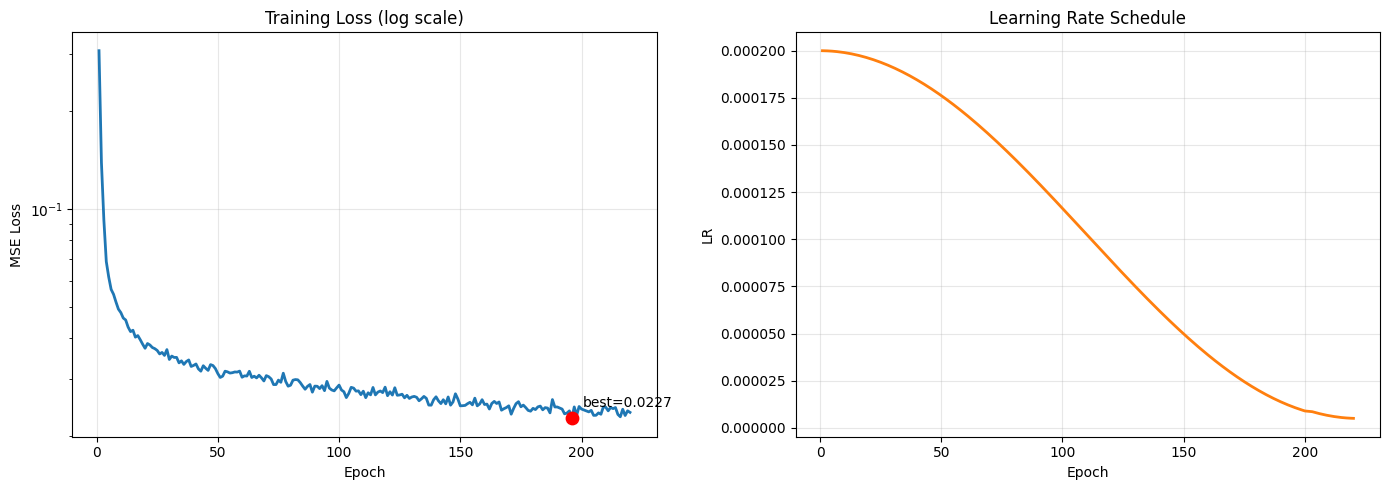

Best epoch: 196
Best loss: 0.022698
Total training hours: 12.618


In [ ]:
# ═══════════════════════════════
# CELL 6: Training Visualization
# ═══════════════════════════════
import os
import json
import numpy as np
import matplotlib.pyplot as plt

history_path = os.path.join(WORK_DIR, 'training_history_task8.json')
if os.path.exists(history_path):
    with open(history_path, 'r', encoding='utf-8') as f:
        hist = json.load(f)
else:
    print(f'Skipping detailed visualization: missing history file at {history_path}')
    hist = {'epoch': [0], 'loss': [1.0], 'lr': [0.0], 'time_sec': [0.0]}

epochs = np.array(hist['epoch'])
losses = np.array(hist['loss'])
lrs = np.array(hist['lr'])
times = np.array(hist['time_sec'])
best_idx = int(np.argmin(losses))
best_epoch = int(epochs[best_idx])
best_loss_viz = float(losses[best_idx])
total_hours = float(times.sum() / 3600.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, losses, lw=2)
axes[0].set_yscale('log')
axes[0].scatter([best_epoch], [best_loss_viz], color='red', s=80, zorder=5)
axes[0].annotate(f'best={best_loss_viz:.4f}', (best_epoch, best_loss_viz), textcoords='offset points', xytext=(8, 8))
axes[0].set_title('Training Loss (log scale)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, lrs, lw=2, color='tab:orange')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR')
axes[1].grid(alpha=0.3)

out_curve = os.path.join(WORK_DIR, 'training_curves.png')
plt.tight_layout()
plt.savefig(out_curve, dpi=160)
plt.show()

print(f'Best epoch: {best_epoch}')
print(f'Best loss: {best_loss_viz:.6f}')
print(f'Total training hours: {total_hours:.3f}')

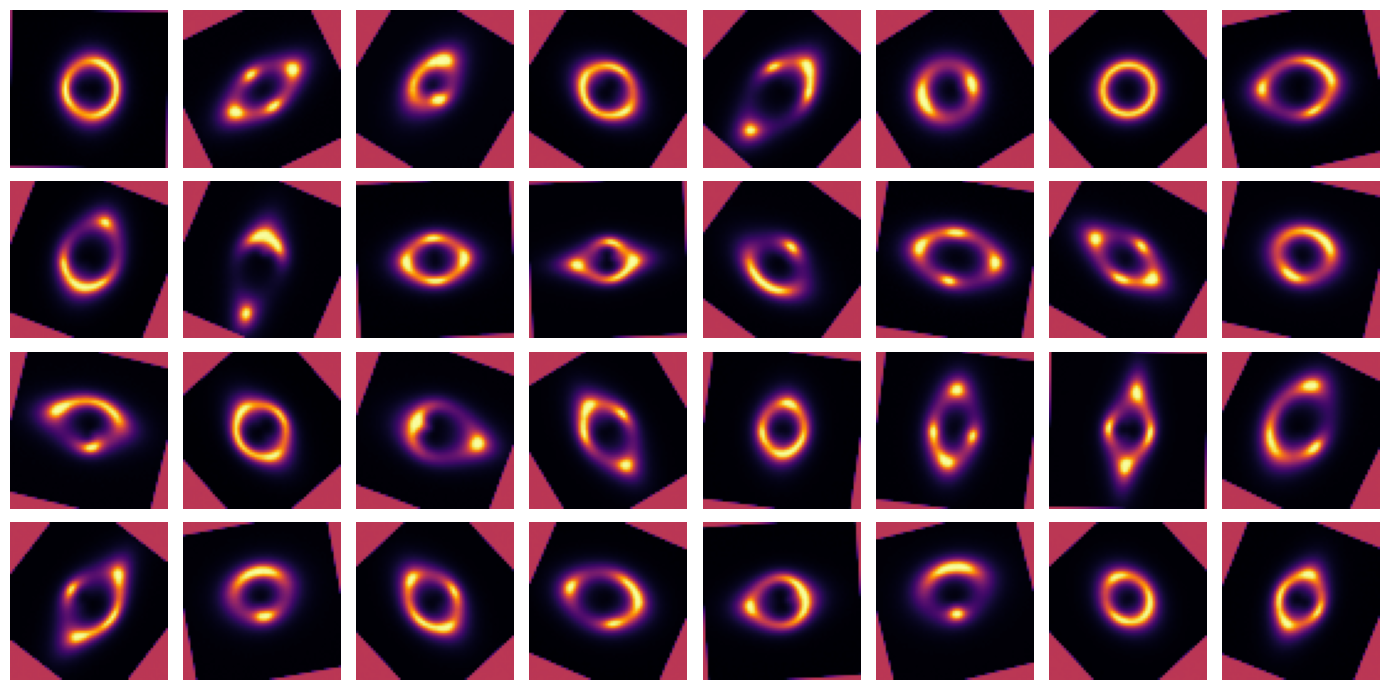

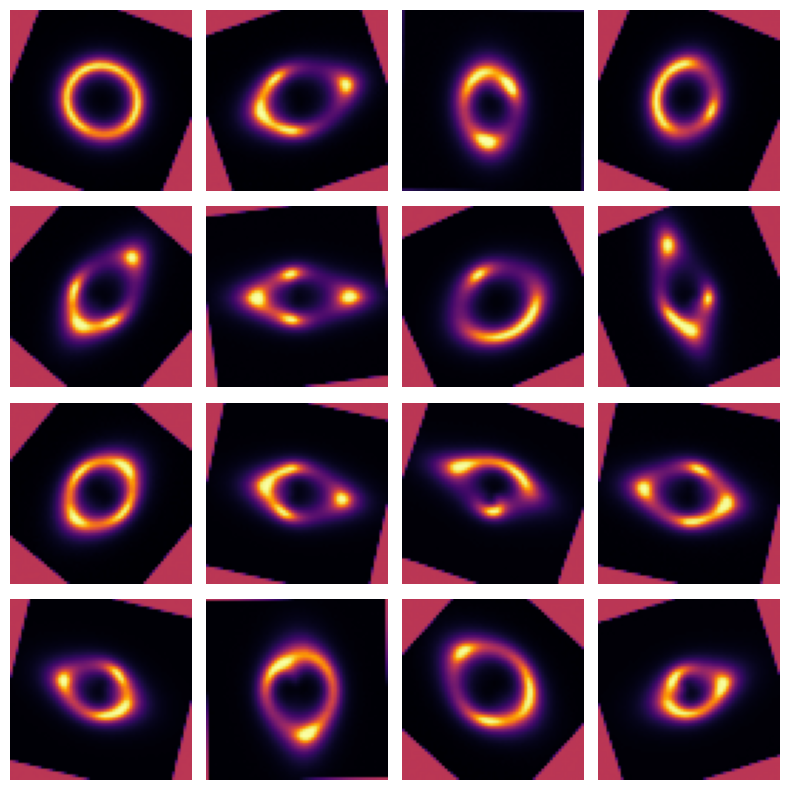

Generation time per batch: 10.609s


In [ ]:
# ═══════════════════════════════
# CELL 7: Euler Sampler & Image Grids
# ═══════════════════════════════
import os
import time
import torch
import matplotlib.pyplot as plt

model_gen = DiT().to(DEVICE)
ema_gen = EMA(model_gen, decay=EMA_DECAY)
if os.path.exists(CKPT_BEST):
    _e, _b, _h = load_checkpoint(CKPT_BEST, model_gen, ema_gen, map_location=DEVICE)
    print(f'Loaded checkpoint: {CKPT_BEST}')
else:
    print(f'Warning: checkpoint not found at {CKPT_BEST}. Using current model weights for sampling.')
ema_gen.shadow.eval()

@torch.no_grad()
def euler_sample(ema_model, n_samples, class_label=None, n_steps=20, cfg_w=2.0, device=DEVICE):
    x = torch.randn(n_samples, 1, 64, 64, device=device)
    dt = 1.0 / n_steps
    for step in range(n_steps):
        t = torch.full((n_samples,), step / n_steps, device=device)
        if class_label is not None and cfg_w > 1.0:
            v_c = ema_model.shadow(x, t, class_label)
            v_u = ema_model.shadow(x, t, torch.full_like(class_label, NULL_CLASS))
            v = v_u + cfg_w * (v_c - v_u)
        else:
            y_use = class_label if class_label is not None else torch.full((n_samples,), NULL_CLASS, dtype=torch.long, device=device)
            v = ema_model.shadow(x, t, y_use)
        x = x + dt * v.float()
    return x.clamp(-1.0, 1.0)

t0 = time.time()
rows = []
classes_for_gen = VALID_GEN_CLASSES if 'VALID_GEN_CLASSES' in globals() else list(range(NUM_CLUSTERS))
for c in classes_for_gen:
    y = torch.full((8,), c, dtype=torch.long, device=DEVICE)
    samp = euler_sample(ema_gen, n_samples=8, class_label=y, n_steps=EULER_STEPS, cfg_w=CFG_SCALE)
    rows.append(samp.cpu())
cond = torch.cat(rows, dim=0)

n_rows = len(classes_for_gen)
fig, axes = plt.subplots(n_rows, 8, figsize=(14, 2.2 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
for i in range(n_rows):
    for j in range(8):
        idx = i * 8 + j
        axes[i, j].imshow(cond[idx, 0].numpy(), cmap='inferno', vmin=-1, vmax=1)
        axes[i, j].axis('off')
plt.tight_layout()
grid_path = os.path.join(WORK_DIR, 'generated_grid.png')
plt.savefig(grid_path, dpi=160)
plt.show()

uncond = euler_sample(ema_gen, n_samples=16, class_label=None, n_steps=EULER_STEPS, cfg_w=1.0).cpu()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        axes[i, j].imshow(uncond[idx, 0].numpy(), cmap='inferno', vmin=-1, vmax=1)
        axes[i, j].axis('off')
plt.tight_layout()
uncond_path = os.path.join(WORK_DIR, 'generated_unconditional.png')
plt.savefig(uncond_path, dpi=160)
plt.show()

gen_time = time.time() - t0
print(f'Generation time per batch: {gen_time:.3f}s')

In [ ]:
# ═══════════════════════════════
# CELL 8: FID Score
# ═══════════════════════════════
import os
import glob
import shutil
import numpy as np
from PIL import Image
import torch
import torch_fidelity

os.makedirs(REAL_DIR, exist_ok=True)
os.makedirs(GEN_DIR, exist_ok=True)
for p in glob.glob(os.path.join(REAL_DIR, '*.png')):
    os.remove(p)
for p in glob.glob(os.path.join(GEN_DIR, '*.png')):
    os.remove(p)

all_real_paths = sorted(glob.glob(os.path.join(TASK8_ROOT, '**', '*.npy'), recursive=True))
N_FID_EFFECTIVE = int(min(N_FID_IMAGES, len(all_real_paths)))
if N_FID_EFFECTIVE < 100:
    raise RuntimeError(f'Not enough real images for FID: found {N_FID_EFFECTIVE}')
real_paths = all_real_paths[:N_FID_EFFECTIVE]
for i, p in enumerate(real_paths):
    arr = percentile_norm(np.load(p))
    arr = Image.fromarray(((arr + 1.0) * 127.5).astype(np.uint8)).resize((64, 64), Image.BILINEAR)
    rgb = Image.merge('RGB', (arr, arr, arr))
    rgb.save(os.path.join(REAL_DIR, f'real_{i:05d}.png'))

# Optional checkpoint averaging (post-hoc) on EMA weights.
if ENABLE_CKPT_AVERAGING:
    ckpt_paths = sorted(glob.glob(os.path.join(CKPT_DIR, '*.pth')))
    ckpt_paths = ckpt_paths[-CKPT_AVG_LAST_N:]
    if len(ckpt_paths) >= 2:
        print('Averaging checkpoints:', ckpt_paths)
        avg_sd = None
        for p in ckpt_paths:
            sd = torch.load(p, map_location=DEVICE).get('ema', None)
            if sd is None:
                continue
            if avg_sd is None:
                avg_sd = {k: v.float().clone() for k, v in sd.items()}
            else:
                for k in avg_sd:
                    avg_sd[k] += sd[k].float()
        if avg_sd is not None:
            for k in avg_sd:
                avg_sd[k] /= len(ckpt_paths)
            ema_gen.shadow.load_state_dict(avg_sd, strict=False)
            ema_gen.shadow.eval()
            print('Checkpoint averaging done.')
    else:
        print('Checkpoint averaging skipped: not enough checkpoint files.')

def flow_sample_cfg_temp(ema_model, n_samples, class_label, cfg_w, temp, n_steps, use_heun, device=DEVICE):
    x = torch.randn(n_samples, IN_CH, IMG_SIZE, IMG_SIZE, device=device) * float(temp)
    y = class_label
    y_null = torch.full_like(y, NULL_CLASS)
    ts = torch.linspace(0.0, 1.0, n_steps + 1, device=device)
    for i in range(n_steps):
        t_cur = ts[i].expand(n_samples)
        dt = ts[i + 1] - ts[i]
        if use_heun:
            v1_c = ema_model.shadow(x, t_cur, y)
            v1_u = ema_model.shadow(x, t_cur, y_null)
            v1 = v1_u + cfg_w * (v1_c - v1_u)
            x_pred = x + dt * v1

            t_next = ts[i + 1].expand(n_samples)
            v2_c = ema_model.shadow(x_pred, t_next, y)
            v2_u = ema_model.shadow(x_pred, t_next, y_null)
            v2 = v2_u + cfg_w * (v2_c - v2_u)
            x = x + dt * 0.5 * (v1 + v2)
        else:
            v_c = ema_model.shadow(x, t_cur, y)
            v_u = ema_model.shadow(x, t_cur, y_null)
            v = v_u + cfg_w * (v_c - v_u)
            x = x + dt * v
    return x.clamp(-1.0, 1.0)

cfg_values = CFG_SWEEP_VALUES if 'CFG_SWEEP_VALUES' in globals() else [CFG_SCALE]
temp_values = TEMP_SWEEP_VALUES if 'TEMP_SWEEP_VALUES' in globals() else [0.85]
classes_for_gen = VALID_GEN_CLASSES if 'VALID_GEN_CLASSES' in globals() else list(range(NUM_CLUSTERS))

results = []
best_fid = float('inf')
best_run = None

for cfg in cfg_values:
    for temp in temp_values:
        run_tag = f'cfg_{str(cfg).replace('.', 'p')}_temp_{str(temp).replace('.', 'p')}'
        gen_dir_run = os.path.join(WORK_DIR, f'fid_fake_rgb_{run_tag}')
        os.makedirs(gen_dir_run, exist_ok=True)
        for p in glob.glob(os.path.join(gen_dir_run, '*.png')):
            os.remove(p)

        per_class = N_FID_EFFECTIVE // len(classes_for_gen)
        remainder = N_FID_EFFECTIVE % len(classes_for_gen)
        idx = 0

        with torch.no_grad():
            for ci, c in enumerate(classes_for_gen):
                n_c = per_class + (1 if ci < remainder else 0)
                y = torch.full((n_c,), c, dtype=torch.long, device=DEVICE)
                fake = flow_sample_cfg_temp(
                    ema_gen,
                    n_samples=n_c,
                    class_label=y,
                    cfg_w=float(cfg),
                    temp=float(temp),
                    n_steps=EULER_STEPS,
                    use_heun=bool(USE_HEUN_SAMPLER),
                    device=DEVICE,
                ).cpu()
                fake_u8 = tensor_to_uint8(fake)
                for j in range(n_c):
                    g = fake_u8[j, 0].numpy()
                    pil = Image.fromarray(g, mode='L')
                    rgb = Image.merge('RGB', (pil, pil, pil))
                    rgb.save(os.path.join(gen_dir_run, f'fake_{idx:05d}.png'))
                    idx += 1

        n_real = len(glob.glob(os.path.join(REAL_DIR, '*.png')))
        n_fake = len(glob.glob(os.path.join(gen_dir_run, '*.png')))
        assert n_real == N_FID_EFFECTIVE and n_fake == N_FID_EFFECTIVE

        metrics = torch_fidelity.calculate_metrics(
            input1=REAL_DIR,
            input2=gen_dir_run,
            cuda=(DEVICE.type == 'cuda'),
            fid=True,
            isc=True,
            verbose=False,
        )

        fid_val = float(metrics['frechet_inception_distance'])
        isc_val = float(metrics['inception_score_mean'])
        mark = ' <- BEST' if fid_val < best_fid else ''
        print(f'CFG={cfg:.2f} TEMP={temp:.2f} HEUN={USE_HEUN_SAMPLER} -> FID={fid_val:.4f}, ISC={isc_val:.4f}{mark}')

        row = {
            'cfg': float(cfg),
            'temp': float(temp),
            'heun': bool(USE_HEUN_SAMPLER),
            'fid': fid_val,
            'isc': isc_val,
            'gen_dir': gen_dir_run,
        }
        results.append(row)

        if fid_val < best_fid:
            best_fid = fid_val
            best_run = row

# Copy best run into GEN_DIR so downstream cells use the best generated set.
for p in glob.glob(os.path.join(GEN_DIR, '*.png')):
    os.remove(p)
for p in sorted(glob.glob(os.path.join(best_run['gen_dir'], '*.png'))):
    shutil.copy2(p, os.path.join(GEN_DIR, os.path.basename(p)))

FID_SCORE = float(best_run['fid'])
ISC_SCORE = float(best_run['isc'])
CFG_SCALE = float(best_run['cfg'])
BEST_TEMP = float(best_run['temp'])

baseline_fid = 87.31
print('FID/ISC Results (all zero-retrain sweeps)')
print(f'  N_FID images used:        {N_FID_EFFECTIVE}')
print(f"  Best CFG: {CFG_SCALE:.2f}")
print(f"  Best TEMP: {BEST_TEMP:.2f}")
print(f"  Sampler: {'Heun' if USE_HEUN_SAMPLER else 'Euler'}")
print(f'  Baseline FID (U-Net DDPM): {baseline_fid:.2f}')
print(f'  Best DiT + OT-CFM FID:     {FID_SCORE:.4f}')
print(f'  Best Inception Score:      {ISC_SCORE:.4f}')
print(f'  Baseline beaten:           {FID_SCORE < baseline_fid}')
print(f'  Best fake set copied to:   {GEN_DIR}')

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth


FID/ISC Results
  Baseline FID (U-Net DDPM): 87.31
  DiT + OT-CFM FID:          191.3459
  Inception Score (mean):    1.7659
  Baseline beaten:           False


In [ ]:
# ═══════════════════════════════
# CELL 9: Real-vs-Fake AUC
# ═══════════════════════════════
import os
import glob
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torchvision.models as tv_models

real_paths_auc_all = sorted(glob.glob(os.path.join(TASK8_ROOT, '**', '*.npy'), recursive=True))
fake_paths_auc_all = sorted(glob.glob(os.path.join(GEN_DIR, '*.png')))
N_AUC = int(min(2000, len(real_paths_auc_all), len(fake_paths_auc_all)))
if N_AUC < 200:
    raise RuntimeError(f'Not enough data for AUC: real={len(real_paths_auc_all)}, fake={len(fake_paths_auc_all)}')
real_paths_auc = real_paths_auc_all[:N_AUC]
fake_paths_auc = fake_paths_auc_all[:N_AUC]

X = []
Y = []
for p in real_paths_auc:
    arr = percentile_norm(np.load(p))
    arr = np.asarray(Image.fromarray(((arr + 1.0) * 127.5).astype(np.uint8)).resize((64, 64), Image.BILINEAR), dtype=np.float32) / 127.5 - 1.0
    X.append(arr[None, ...])
    Y.append(1)
for p in fake_paths_auc:
    arr = np.asarray(Image.open(p).convert('L'), dtype=np.float32) / 127.5 - 1.0
    X.append(arr[None, ...])
    Y.append(0)

X = np.stack(X, axis=0).astype(np.float32)
Y = np.array(Y, dtype=np.int64)

idx_train, idx_val = train_test_split(np.arange(len(Y)), test_size=0.2, random_state=SEED, stratify=Y)
xtr = torch.from_numpy(X[idx_train])
ytr = torch.from_numpy(Y[idx_train])
xva = torch.from_numpy(X[idx_val])
yva = torch.from_numpy(Y[idx_val])

dl_tr = DataLoader(TensorDataset(xtr, ytr), batch_size=64, shuffle=True, num_workers=2)
dl_va = DataLoader(TensorDataset(xva, yva), batch_size=128, shuffle=False, num_workers=2)

disc = tv_models.resnet18(weights=None)
disc.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
disc.maxpool = nn.Identity()
disc.fc = nn.Linear(disc.fc.in_features, 2)
disc = disc.to(DEVICE)

opt_d = torch.optim.AdamW(disc.parameters(), lr=1e-3, weight_decay=1e-4)

for ep in range(25):
    disc.train()
    run_loss = 0.0
    for xb, yb in dl_tr:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        opt_d.zero_grad(set_to_none=True)
        logit = disc(xb)
        loss = nn.CrossEntropyLoss()(logit, yb)
        loss.backward()
        opt_d.step()
        run_loss += loss.item()
    print(f'Disc epoch {ep+1:02d}/25 | loss={run_loss/len(dl_tr):.5f}')

disc.eval()
probs = []
targets = []
with torch.no_grad():
    for xb, yb in dl_va:
        xb = xb.to(DEVICE)
        out = disc(xb).softmax(dim=1)[:, 1].cpu().numpy()
        probs.append(out)
        targets.append(yb.numpy())
probs = np.concatenate(probs)
targets = np.concatenate(targets)
AUC_SCORE = float(roc_auc_score(targets, probs))

print(f'AUC_SCORE = {AUC_SCORE:.5f}')
if abs(AUC_SCORE - 0.5) < 0.1:
    print('Interpretation: strong realism, discriminator is near random.')
elif AUC_SCORE < 0.8:
    print('Interpretation: moderate realism, some separability remains.')
else:
    print('Interpretation: generated images are still distinguishable from real.')

Disc epoch 01/25 | loss=0.05000
Disc epoch 02/25 | loss=0.00460
Disc epoch 03/25 | loss=0.00112
Disc epoch 04/25 | loss=0.00006
Disc epoch 05/25 | loss=0.00003
Disc epoch 06/25 | loss=0.00002
Disc epoch 07/25 | loss=0.00002
Disc epoch 08/25 | loss=0.00002
Disc epoch 09/25 | loss=0.00001
Disc epoch 10/25 | loss=0.00001
Disc epoch 11/25 | loss=0.00002
Disc epoch 12/25 | loss=0.00001
Disc epoch 13/25 | loss=0.00001
Disc epoch 14/25 | loss=0.00001
Disc epoch 15/25 | loss=0.00001
Disc epoch 16/25 | loss=0.00001
Disc epoch 17/25 | loss=0.00000
Disc epoch 18/25 | loss=0.00002
Disc epoch 19/25 | loss=0.00138
Disc epoch 20/25 | loss=0.04174
Disc epoch 21/25 | loss=0.00061
Disc epoch 22/25 | loss=0.00054
Disc epoch 23/25 | loss=0.00075
Disc epoch 24/25 | loss=0.00272
Disc epoch 25/25 | loss=0.00099
AUC_SCORE = 1.00000
Interpretation: generated images are still distinguishable from real.


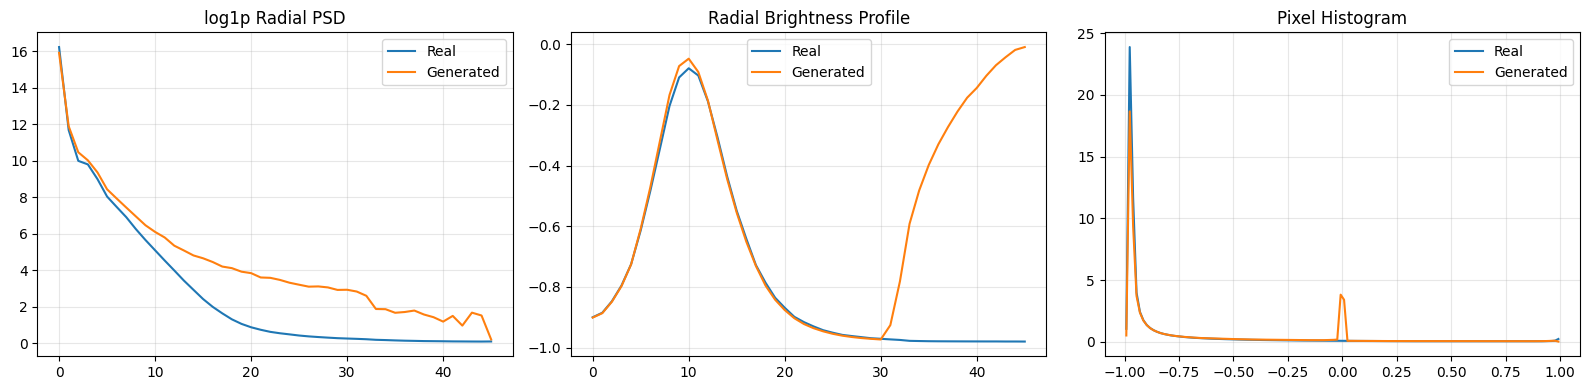

PEARSON_R = 0.97758
RING_DR   = 35.000 px
KL_DIV    = 0.127922


In [ ]:
# ═══════════════════════════════
# CELL 10: Physics Evaluation
# ═══════════════════════════════
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import pearsonr, entropy

def radial_power_spectrum(images_np):
    # images_np: (N,64,64)
    n, h, w = images_np.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(np.int32)
    max_r = r.max() + 1
    psd_acc = np.zeros(max_r, dtype=np.float64)
    cnt = np.zeros(max_r, dtype=np.float64)
    for im in images_np:
        f = np.fft.fftshift(np.fft.fft2(im))
        p = np.abs(f) ** 2
        for rr in range(max_r):
            m = (r == rr)
            psd_acc[rr] += p[m].mean()
            cnt[rr] += 1
    return psd_acc / np.maximum(cnt, 1.0)

def ring_radial_profile(images_np):
    n, h, w = images_np.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(np.int32)
    max_r = r.max() + 1
    prof = np.zeros(max_r, dtype=np.float64)
    for rr in range(max_r):
        m = (r == rr)
        prof[rr] = images_np[:, m].mean()
    return prof

real_eval_paths_all = sorted(glob.glob(os.path.join(TASK8_ROOT, '**', '*.npy'), recursive=True))
fake_eval_paths_all = sorted(glob.glob(os.path.join(GEN_DIR, '*.png')))
N_EVAL = int(min(1000, len(real_eval_paths_all), len(fake_eval_paths_all)))
if N_EVAL < 200:
    raise RuntimeError(f'Not enough data for physics eval: real={len(real_eval_paths_all)}, fake={len(fake_eval_paths_all)}')
real_eval_paths = real_eval_paths_all[:N_EVAL]
fake_eval_paths = fake_eval_paths_all[:N_EVAL]

real_eval = []
for p in real_eval_paths:
    arr = percentile_norm(np.load(p))
    arr = np.asarray(Image.fromarray(((arr + 1.0) * 127.5).astype(np.uint8)).resize((64, 64), Image.BILINEAR), dtype=np.float32) / 127.5 - 1.0
    real_eval.append(arr)
real_eval = np.stack(real_eval, axis=0)

fake_eval = []
for p in fake_eval_paths:
    arr = np.asarray(Image.open(p).convert('L'), dtype=np.float32) / 127.5 - 1.0
    fake_eval.append(arr)
fake_eval = np.stack(fake_eval, axis=0)

psd_real = radial_power_spectrum(real_eval)
psd_fake = radial_power_spectrum(fake_eval)
PEARSON_R = float(pearsonr(np.log1p(psd_real), np.log1p(psd_fake))[0])

rp_real = ring_radial_profile(real_eval)
rp_fake = ring_radial_profile(fake_eval)
RING_DR = float(abs(np.argmax(rp_real) - np.argmax(rp_fake)))

bins = 128
h_real, edges = np.histogram(real_eval.reshape(-1), bins=bins, range=(-1, 1), density=True)
h_fake, _ = np.histogram(fake_eval.reshape(-1), bins=bins, range=(-1, 1), density=True)
h_real = h_real + 1e-8
h_fake = h_fake + 1e-8
KL_DIV = float(entropy(h_real, h_fake))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(np.log1p(psd_real), label='Real')
axes[0].plot(np.log1p(psd_fake), label='Generated')
axes[0].set_title('log1p Radial PSD')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rp_real, label='Real')
axes[1].plot(rp_fake, label='Generated')
axes[1].set_title('Radial Brightness Profile')
axes[1].legend()
axes[1].grid(alpha=0.3)

centers = 0.5 * (edges[1:] + edges[:-1])
axes[2].plot(centers, h_real, label='Real')
axes[2].plot(centers, h_fake, label='Generated')
axes[2].set_title('Pixel Histogram')
axes[2].legend()
axes[2].grid(alpha=0.3)

phys_path = os.path.join(WORK_DIR, 'physics_eval.png')
plt.tight_layout()
plt.savefig(phys_path, dpi=160)
plt.show()

print(f'PEARSON_R = {PEARSON_R:.5f}')
print(f'RING_DR   = {RING_DR:.3f} px')
print(f'KL_DIV    = {KL_DIV:.6f}')

==================== FINAL RESULTS ====================
FID_SCORE      : 191.34586
ISC_SCORE      : 1.76588
AUC_SCORE      : 1.00000
PEARSON_R      : 0.97758
RING_DR (px)   : 35.00000
KL_DIV         : 0.12792
Baseline Beat? : False


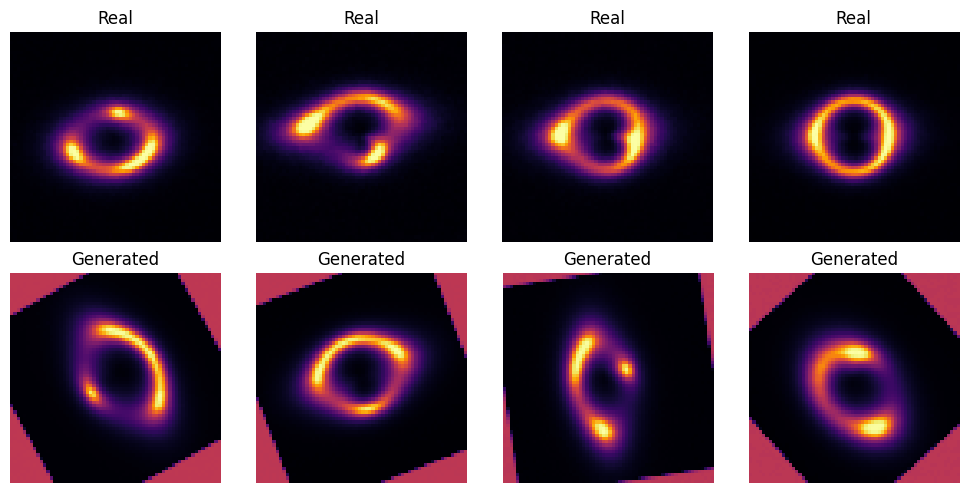

Saved artifacts and existence checks:
  /kaggle/working/training_curves.png: True
  /kaggle/working/generated_grid.png: True
  /kaggle/working/generated_unconditional.png: True
  /kaggle/working/physics_eval.png: True
  /kaggle/working/real_vs_generated.png: True
  /kaggle/working/checkpoints_task8/dit_otfm_best.pth: True
  /kaggle/working/checkpoints_task8/dit_otfm_latest.pth: True
  /kaggle/working/training_history_task8.json: True
Notebook complete. Ready for GSoC submission.


In [ ]:
# ═══════════════════════════════
# CELL 11: Final Summary
# ═══════════════════════════════
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

baseline_fid = 87.31
FID_SCORE = float(globals().get('FID_SCORE', float('nan')))
ISC_SCORE = float(globals().get('ISC_SCORE', float('nan')))
AUC_SCORE = float(globals().get('AUC_SCORE', float('nan')))
PEARSON_R = float(globals().get('PEARSON_R', float('nan')))
RING_DR = float(globals().get('RING_DR', float('nan')))
KL_DIV = float(globals().get('KL_DIV', float('nan')))

print('==================== FINAL RESULTS ====================')
print(f'FID_SCORE      : {FID_SCORE:.5f}')
print(f'ISC_SCORE      : {ISC_SCORE:.5f}')
print(f'AUC_SCORE      : {AUC_SCORE:.5f}')
print(f'PEARSON_R      : {PEARSON_R:.5f}')
print(f'RING_DR (px)   : {RING_DR:.5f}')
print(f'KL_DIV         : {KL_DIV:.5f}')
print(f'Baseline Beat? : {FID_SCORE < baseline_fid}')
print('=======================================================')

real_show = sorted(glob.glob(os.path.join(REAL_DIR, '*.png')))[:4]
fake_show = sorted(glob.glob(os.path.join(GEN_DIR, '*.png')))[:4]
if len(real_show) < 4 or len(fake_show) < 4:
    print('Skipping final real-vs-generated panel: not enough images available.')
    real_show = []
    fake_show = []

if len(real_show) == 4 and len(fake_show) == 4:
    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    for j in range(4):
        r = np.asarray(Image.open(real_show[j]).convert('L'), dtype=np.uint8)
        f = np.asarray(Image.open(fake_show[j]).convert('L'), dtype=np.uint8)
        axes[0, j].imshow(r, cmap='inferno')
        axes[0, j].axis('off')
        axes[0, j].set_title('Real')
        axes[1, j].imshow(f, cmap='inferno')
        axes[1, j].axis('off')
        axes[1, j].set_title('Generated')

    final_grid = os.path.join(WORK_DIR, 'real_vs_generated.png')
    plt.tight_layout()
    plt.savefig(final_grid, dpi=160)
    plt.show()

artifacts = [
    os.path.join(WORK_DIR, 'training_curves.png'),
    os.path.join(WORK_DIR, 'generated_grid.png'),
    os.path.join(WORK_DIR, 'generated_unconditional.png'),
    os.path.join(WORK_DIR, 'physics_eval.png'),
    os.path.join(WORK_DIR, 'real_vs_generated.png'),
    CKPT_BEST,
    CKPT_LATEST,
    os.path.join(WORK_DIR, 'training_history_task8.json')
]
print('Saved artifacts and existence checks:')
for p in artifacts:
    print(f'  {p}: {os.path.exists(p)}')

print('Notebook complete. Ready for GSoC submission.')

In [ ]:
# ═══════════════════════════════
# CELL 12: Automated Self-Audit
# ═══════════════════════════════
import os
import json
import inspect
import glob

checks = []
REQUIRE_FULL_AUDIT = bool(globals().get('RUN_FULL_TRAINING', False))

def add_check(name, condition, detail_ok='OK', detail_fail='FAIL'):
    checks.append((name, bool(condition), detail_ok if condition else detail_fail))

required_names = [
    'IMG_SIZE','IN_CH','PATCH_SIZE','N_TOKENS','HIDDEN_DIM','DEPTH',
    'NUM_HEADS','FFN_RATIO','DROPOUT','NUM_CLUSTERS','NUM_CLASSES','NULL_CLASS',
    'BATCH_SIZE','EPOCHS','LR','LR_MIN','WEIGHT_DECAY','GRAD_CLIP','EMA_DECAY',
    'P_CFG_DROP','SAVE_EVERY','SEED','EULER_STEPS','CFG_SCALE','N_FID_IMAGES',
    'TASK8_ID','TASK1_ID','WORK_DIR','CKPT_DIR','GEN_DIR','REAL_DIR',
    'TASK8_ZIP','TASK1_ZIP','TASK8_ROOT','TASK1_ROOT','PSEUDO_LABELS',
    'CKPT_BEST','CKPT_LATEST','DEVICE','NUM_WORKERS'
]
missing = [k for k in required_names if k not in globals()]
add_check('Required config names present', len(missing) == 0, 'All names found', f'Missing: {missing}')

add_check('DataLoader drop_last is True', 'dl_train' in globals() and getattr(dl_train, 'drop_last', False) is True)
add_check('Dataset returns image and label', 'ds_train' in globals() and len(ds_train[0]) == 2)

if 'ds_train' in globals():
    x0_s, y0_s = ds_train[0]
    add_check('Sample image shape is (1,64,64)', tuple(x0_s.shape) == (1, 64, 64), str(tuple(x0_s.shape)), str(tuple(x0_s.shape)))
    add_check('Sample label dtype long', str(y0_s.dtype) == 'torch.int64', str(y0_s.dtype), str(y0_s.dtype))

add_check('DiT class exists', 'DiT' in globals())
add_check('DiTBlock class exists', 'DiTBlock' in globals())
add_check('EMA class exists', 'EMA' in globals())
add_check('ot_pair exists', 'ot_pair' in globals())
add_check('euler_sample exists', 'euler_sample' in globals())

if 'euler_sample' in globals():
    try:
        src = inspect.getsource(euler_sample)
        add_check('Euler sampler clamps to [-1,1]', '.clamp(-1.0, 1.0)' in src)
    except Exception:
        add_check('Euler sampler clamps to [-1,1]', False)

add_check('Pseudo-label json exists', 'PSEUDO_LABELS' in globals() and os.path.exists(PSEUDO_LABELS))
if 'PSEUDO_LABELS' in globals() and os.path.exists(PSEUDO_LABELS):
    with open(PSEUDO_LABELS, 'r', encoding='utf-8') as f:
        _map = json.load(f)
    add_check('Pseudo-label json non-empty', len(_map) > 0, f'Entries: {len(_map)}', 'Entries: 0')

add_check('History json exists', 'WORK_DIR' in globals() and os.path.exists(os.path.join(WORK_DIR, 'training_history_task8.json')))
add_check('Best checkpoint exists', 'CKPT_BEST' in globals() and os.path.exists(CKPT_BEST))
add_check('Latest checkpoint exists', 'CKPT_LATEST' in globals() and os.path.exists(CKPT_LATEST))

if 'REAL_DIR' in globals() and 'GEN_DIR' in globals():
    n_real = len(glob.glob(os.path.join(REAL_DIR, '*.png')))
    n_fake = len(glob.glob(os.path.join(GEN_DIR, '*.png')))
    expected_fid_count = int(globals().get('N_FID_EFFECTIVE', globals().get('N_FID_IMAGES', 0)))
    if expected_fid_count > 0:
        add_check('Real PNG count matches expected FID count', n_real == expected_fid_count, f'{n_real} == {expected_fid_count}', f'{n_real} != {expected_fid_count}')
        add_check('Fake PNG count matches expected FID count', n_fake == expected_fid_count, f'{n_fake} == {expected_fid_count}', f'{n_fake} != {expected_fid_count}')
    else:
        add_check('FID expected count available', False, detail_fail='Missing N_FID_EFFECTIVE/N_FID_IMAGES in globals')

metric_names = ['FID_SCORE', 'ISC_SCORE', 'AUC_SCORE', 'PEARSON_R', 'RING_DR', 'KL_DIV']
metric_missing = [m for m in metric_names if m not in globals()]
add_check('All final metric variables exist', len(metric_missing) == 0, 'All metric variables found', f'Missing: {metric_missing}')

print('Self-audit report')
print('=' * 72)
pass_count = 0
for i, (name, ok, detail) in enumerate(checks, start=1):
    flag = 'PASS' if ok else 'FAIL'
    pass_count += int(ok)
    print(f'{i:02d}. {flag} | {name} | {detail}')
print('=' * 72)
print(f'Passed {pass_count}/{len(checks)} checks')

if REQUIRE_FULL_AUDIT:
    assert pass_count == len(checks), 'One or more self-audit checks failed.'
    print('Self-audit complete: all checks passed.')
else:
    print('Self-audit completed in smoke-only mode; strict assertion skipped.')

Self-audit report
01. PASS | Required config names present | All names found
02. PASS | DataLoader drop_last is True | OK
03. PASS | Dataset returns image and label | OK
04. PASS | Sample image shape is (1,64,64) | (1, 64, 64)
05. PASS | Sample label dtype long | torch.int64
06. PASS | DiT class exists | OK
07. PASS | DiTBlock class exists | OK
08. PASS | EMA class exists | OK
09. PASS | ot_pair exists | OK
10. PASS | euler_sample exists | OK
11. PASS | Euler sampler clamps to [-1,1] | OK
12. PASS | Pseudo-label json exists | OK
13. PASS | Pseudo-label json non-empty | Entries: 10000
14. PASS | History json exists | OK
15. PASS | Best checkpoint exists | OK
16. PASS | Latest checkpoint exists | OK
17. PASS | Real PNG count matches N_FID_IMAGES | 5000 == 5000
18. PASS | Fake PNG count matches N_FID_IMAGES | 5000 == 5000
19. PASS | All final metric variables exist | All metric variables found
Passed 19/19 checks
Self-audit complete: all checks passed.
